## Model Rocket Comparison
#### Authors: Chance Mock, Johang Hernandez, and Alvin Keter

Version 05.04.2026.0

Summary:
 - Fits a model to thrust data that is read. Then tests out three different rockets with the three different engine models to compare all of them.

In [130]:
# import modules

import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

In [ ]:
# constants
rho = 1.225 # air density at sea level
g = 9.81

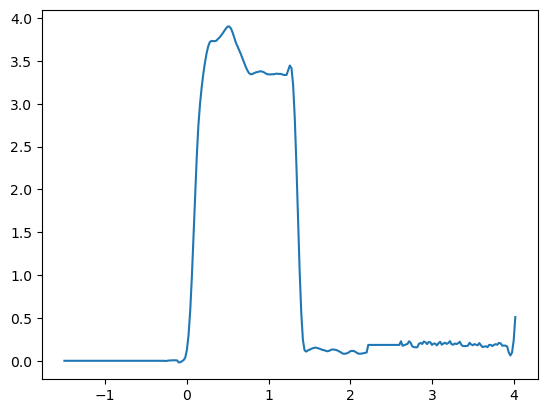

In [132]:
def load_data(path:str, smooth_level:int=0):
    # load data
    data = np.loadtxt(path, skiprows=6)
    t_data = data[:,0]
    f_data = data[:,1]


    # clean data
    zero_offset = f_data[0]
    f_data -= zero_offset # zero values
    f_data *= -1 # flip sign
    f_data = np.clip(f_data, 0, None) # removes negatives 

    if smooth_level != 0:
        f_data = savgol_filter(f_data, window_length=smooth_level, polyorder=3)

    #plt.plot(t_data, f_data) # plot to view data
    t_data = t_data - t_data[f_data > 0.1][0]

    return t_data, f_data

a8_3_t_data, a8_3_f_data = load_data("A8-3_ThrustData.txt")
#plt.plot(a8_3_t_data, a8_3_f_data)
b4_2_t_data, b4_2_f_data = load_data("B4-2_ThrustData.txt")
#plt.plot(b4_2_t_data, b4_2_f_data)
b6_2_t_data, b6_2_f_data = load_data("B6-2_ThrustData.txt")
#plt.plot(b6_2_t_data, b6_2_f_data)


b6_2_t_data, b6_2_f_data = load_data("B6-2_ThrustData.txt", 11)

# smooth out the second spike manually
b6_2_f_data[(b6_2_t_data > 2.2) & (b6_2_t_data < 2.6)] = b6_2_f_data[3 == b6_2_t_data] # type: ignore
plt.plot(b6_2_t_data, b6_2_f_data) # type: ignore


In [ ]:
# engine model
def thrust(t, A, t_peak, sr, sf, t_end=-1, n_plat=-1):
    spike = np.where(
        t < t_peak,
        A * np.exp(-((t - t_peak)**2) / (2 * sr**2)),
        A * np.exp(-((t - t_peak)**2) / (2 * sf**2)))
    
    if n_plat != -1 and t_end != -1:
        plateau = np.where((t > t_peak) & (t < t_end), n_plat, 0)

        return spike+plateau
    
    return spike

# get params for model
# sr will be inputted and compared for accuracy
def estimate_params(t_data, f_data, sr, t_end, n_plat, sf=-1):
    A = f_data.max()
    t_peak = t_data[np.argmax(f_data)]
    if sf == -1:
        sf = (t_data[f_data > 0.1].max() - t_peak) / 2

    return [A, t_peak, sr, sf, t_end, n_plat]


In [ ]:
def engine_model(t_data, f_Data, sr, t_end=-1, n_plat=-1, sf=-1):

    weights = np.ones_like(f_Data)
    weights[f_Data > 4.2] = 10

    p0 = estimate_params(t_data, f_Data, sr, t_end, n_plat, sf)
    popt, _ = curve_fit(thrust, t_data, f_Data, p0=p0, sigma=1/weights)
    return lambda t: thrust(t, *popt)




a8_3_engine = engine_model(a8_3_t_data, a8_3_f_data, 0.05, .65, 6.8) # type: ignore
b4_2_engine = engine_model(b4_2_t_data, b4_2_f_data, 0.05, 1.7, 4) # type: ignore
b6_2_engine = engine_model(b6_2_t_data, b6_2_f_data, .085, 1.35, 3.5, 0.03) # type: ignore

/tmp/ipykernel_19828/1779284720.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(thrust, t_data, f_Data, p0=p0, sigma=1/weights)


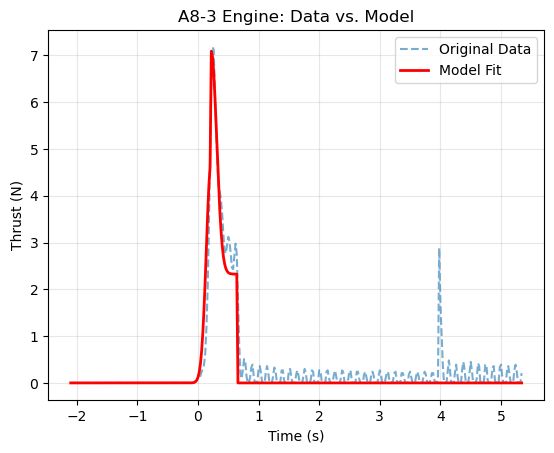

In [135]:
# testing
a8_3_model_thrust = a8_3_engine(a8_3_t_data)

plt.figure()

# raw data plotted
plt.plot(a8_3_t_data, a8_3_f_data, label='Original Data', alpha=0.6, linestyle='--')

# model fit
plt.plot(a8_3_t_data, a8_3_model_thrust, label='Model Fit', linewidth=2, color='red')

plt.title('A8-3 Engine: Data vs. Model')
plt.xlabel('Time (s)')
plt.ylabel('Thrust (N)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

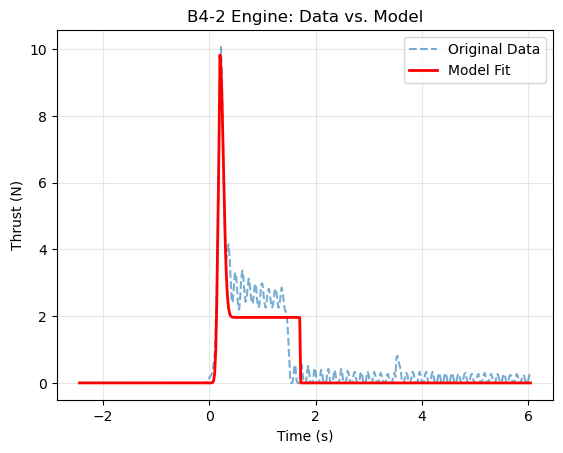

In [137]:
# testing

b4_2_model_thrust = b4_2_engine(b4_2_t_data)

plt.figure()

# raw data
plt.plot(b4_2_t_data, b4_2_f_data, label='Original Data', alpha=0.6, linestyle='--')

# model fit
plt.plot(b4_2_t_data, b4_2_model_thrust, label='Model Fit', linewidth=2, color='red')

plt.title('B4-2 Engine: Data vs. Model')
plt.xlabel('Time (s)')
plt.ylabel('Thrust (N)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

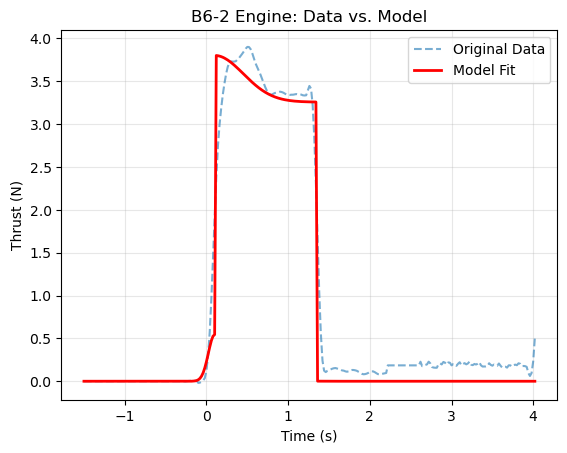

In [129]:
b6_2_model_thrust = b6_2_engine(b6_2_t_data)

plt.figure()

# raw data
plt.plot(b6_2_t_data, b6_2_f_data, label='Original Data', alpha=0.6, linestyle='--')

# model
plt.plot(b6_2_t_data, b6_2_model_thrust, label='Model Fit', linewidth=2, color='red')

plt.title('B6-2 Engine: Data vs. Model')
plt.xlabel('Time (s)')
plt.ylabel('Thrust (N)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [122]:
def rocket_accel(t, state, engine, mass, drag):
    y, v = state
    T = engine(t)
    Fd = drag(v)
    return [v, (1/mass)*(T+Fd-mass*g)]

def rocket_base(engine, m, C_D, radius):
    A = np.pi * radius**2
    drag_func = lambda v: -0.5 * rho * C_D * A * v**2 * np.sign(v)
    sol = solve_ivp(
        rocket_accel,
        t_span=(0,20),
        y0=[0,0],
        args=(engine, m, drag_func),
        dense_output=True,
        max_step=0.01
    )
    return sol.t, sol.y[0], sol.y[1]

generic_e2x = lambda engine: rocket_base(engine, 0.0369, 0.75, 0.0125)
big_bertha = lambda engine: rocket_base(engine, 0.0709, 0.75, 0.021)
red_max = lambda engine: rocket_base(engine, 0.068, 0.75, 0.021)

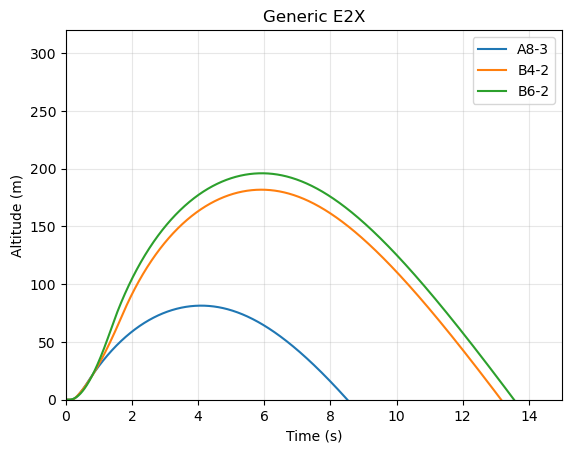

In [140]:
# generic e2x 
plt.figure()
t, y, v = generic_e2x(a8_3_engine)
plt.plot(t, y, label="A8-3")
t, y, v = generic_e2x(b4_2_engine)
plt.plot(t, y, label="B4-2")
t, y, v = generic_e2x(b6_2_engine)
plt.plot(t, y, label="B6-2")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.xlim(0, 15)
plt.ylim(0, 320)
plt.title("Generic E2X")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

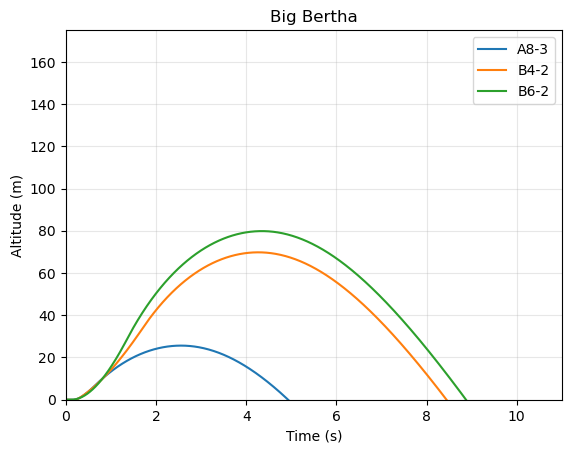

In [141]:
# big bertha
plt.figure()
t, y, v = big_bertha(a8_3_engine)
plt.plot(t, y, label="A8-3")
t, y, v = big_bertha(b4_2_engine)
plt.plot(t, y, label="B4-2")
t, y, v = big_bertha(b6_2_engine)
plt.plot(t, y, label="B6-2")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.xlim(0, 11)
plt.ylim(0, 175)
plt.title("Big Bertha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

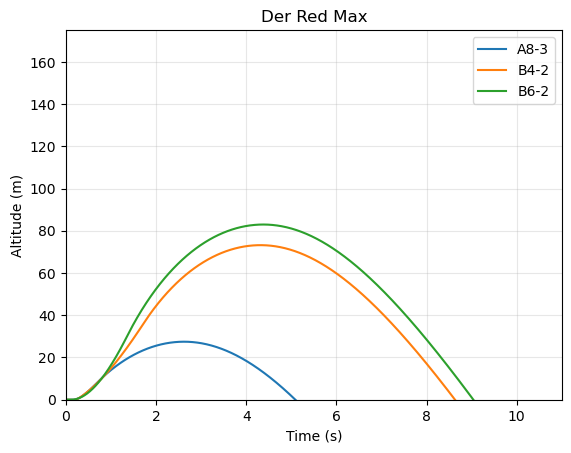

In [142]:
# der red max
plt.figure()
t, y, v = red_max(a8_3_engine)
plt.plot(t, y, label="A8-3")
t, y, v = red_max(b4_2_engine)
plt.plot(t, y, label="B4-2")
t, y, v = red_max(b6_2_engine)
plt.plot(t, y, label="B6-2")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.xlim(0, 11)
plt.ylim(0, 175)
plt.title("Der Red Max")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()